In [1]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from matplotlib import pyplot as plt
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
)

from estuary.util.img import false_color

In [2]:
SAVE_DIR = Path("/Users/kyledorman/data/estuary/display/paper_figures_2_class")
SAVE_DIR.mkdir(exist_ok=True, parents=True)

In [3]:
def inspect_row(iii, suffix_t, suffix_p, title_left, title_right, save_dir=None):
    _, row = next(iii)
    if "acquired" in row:
        date = str(row.acquire.date())
    else:
        date = str(row[f"acquired{suffix_p}"].date())

    with rasterio.open(row[f"source_tif{suffix_t}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        t = false_color(data, nodata)

    with rasterio.open(row[f"source_tif{suffix_p}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        p = false_color(data, nodata)

    label_t = row[f"label{suffix_t}"]
    label_p = row[f"label{suffix_p}"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].set_title(f"{title_left} Label: {label_t.capitalize()}")
    axes[1].set_title(f"{title_right} Label: {label_p.capitalize()}")

    axes[0].imshow(t)
    axes[0].axis("off")
    axes[1].imshow(p)
    axes[1].axis("off")

    fig.tight_layout()

    if save_dir is not None:
        label_t = label_t.replace(" ", "_")
        label_p = label_p.replace(" ", "_")
        plt.savefig(save_dir / f"{row.region}_{label_t}_{label_p}_{date}.png", dpi=300)

    plt.show()

In [4]:
BASE = Path("/Volumes/x10pro/estuary/")

In [5]:
gdf = gpd.read_file(BASE / "geos/ca_data_w_empa_pmep_usgs.geojson")
gdf = gdf[~gdf.skipped].copy()
gdf = gdf.set_index("Site code")
gdf.head(3)

,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,...,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,usgs_station_nm,usgs_site_no,usgs_site_latitude,usgs_site_longitude,geometry
Site code,,,,,,,,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,...,SC-LPL,32.933,-117.260,32.931536,-117.256714,None,None,None,None,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,...,SC-ZUM,34.015,-118.821,34.014565,-118.820618,None,None,None,None,"POLYGON ((-118.81685 34.01177, -118.81699 34.0..."
21,Ventura River,False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,4010_Ventura River,...,SC-VEN,34.276,-119.308,34.277309,-119.308329,None,None,None,None,"POLYGON ((-119.30473 34.27203, -119.3049 34.27..."


In [6]:
ss_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat/labels.csv")
ss_df = ss_df[ss_df.region.isin(gdf.index)].copy()
ss_df = ss_df[ss_df.label != "unsure"].copy()
ss_df["acquired"] = pd.to_datetime(ss_df["acquired"], errors="coerce", utc=True)

ssw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat_water/labels.csv")
ssw_df = ssw_df[ssw_df.region.isin(gdf.index)].copy()
ssw_df = ssw_df[ssw_df.label != "unsure"].copy()
ssw_df["acquired"] = pd.to_datetime(ssw_df["acquired"], errors="coerce", utc=True)

ss_df.head()

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-20 17:07:34+00:00,skysat,2024,10,20241020_170734_ssc13_u0001
1,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-21 16:24:30+00:00,skysat,2024,10,20241021_162430_ssc4_u0001
2,14,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001
3,15,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001
4,16,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001



Per-region label statistics

| Metric        |   Min |   Mean |   Max |
|:--------------|------:|-------:|------:|
| n             |  99   |  186   | 252   |
| Closed %      |   1   |   40.3 |  81.7 |
| Perched %     |   0   |    7.7 |  42.7 |
| Open %        |   0.9 |   32.2 |  87.5 |
| Low quality % |   1   |   19.8 |  41.7 |


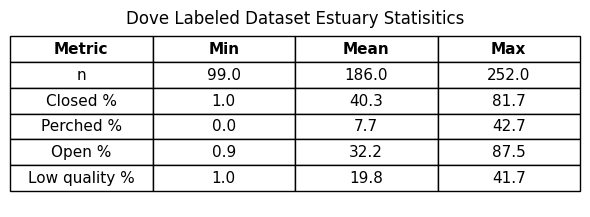

In [11]:
from pathlib import Path

import pandas as pd

SAVE_DIR.mkdir(parents=True, exist_ok=True)

d_df = pd.read_csv("/Users/kyledorman/data/estuary/dataset/train.csv")
d_df["acquired"] = pd.to_datetime(d_df["acquired"], errors="coerce", utc=True)
d_df = d_df[d_df.region.isin(gdf.index)].copy()


# ----------------------------
# Remap labels
# ----------------------------
def remap_label(x):
    x = str(x).strip().lower()
    mapping = {
        "closed": "closed",
        "perched open": "perched",
        "perched": "perched",
        "open": "open",
        "unsure": "low quality",
        "low quality": "low quality",
    }
    return mapping.get(x, x)


d_df["label_clean"] = d_df["label"].map(remap_label)


# ----------------------------
# Per-region statistics
# ----------------------------
region_stats = d_df.groupby("region").apply(
    lambda g: pd.Series(
        {
            "n": len(g),
            "closed": (g.label_clean == "closed").mean() * 100,
            "perched": (g.label_clean == "perched").mean() * 100,
            "open": (g.label_clean == "open").mean() * 100,
            "low quality": (g.label_clean == "low quality").mean() * 100,
        }
    ),
    include_groups=False,
)

# ----------------------------
# Aggregate summary
# ----------------------------
summary = pd.DataFrame(
    {
        "Metric": [
            "n",
            "Closed %",
            "Perched %",
            "Open %",
            "Low quality %",
        ],
        "Min": [
            region_stats["n"].min().astype(int),
            region_stats["closed"].min().round(1),
            region_stats["perched"].min().round(1),
            region_stats["open"].min().round(1),
            region_stats["low quality"].min().round(1),
        ],
        "Mean": [
            region_stats["n"].mean().astype(int),
            region_stats["closed"].mean().round(1),
            region_stats["perched"].mean().round(1),
            region_stats["open"].mean().round(1),
            region_stats["low quality"].mean().round(1),
        ],
        "Max": [
            region_stats["n"].max().astype(int),
            region_stats["closed"].max().round(1),
            region_stats["perched"].max().round(1),
            region_stats["open"].max().round(1),
            region_stats["low quality"].max().round(1),
        ],
    }
)

print("\nPer-region label statistics\n")
print(summary.to_markdown(index=False))


# ----------------------------
# Save CSV
# ----------------------------
summary.to_csv(SAVE_DIR / "region_label_stats_summary.csv", index=False)


# ----------------------------
# Save PNG (for Google Docs)
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis("off")

tbl = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    loc="center",
    cellLoc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

fig.suptitle("Dove Labeled Dataset Estuary Statisitics", y=0.85)
fig.tight_layout()
plt.savefig(SAVE_DIR / "region_label_stats_summary.png", dpi=300, bbox_inches="tight")
plt.show()

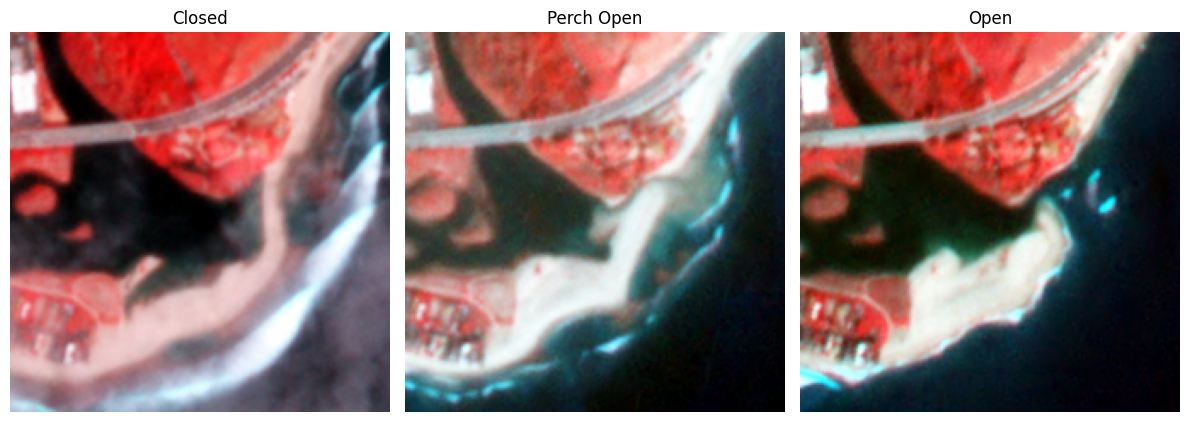

In [12]:
region = 2145

a = d_df[(d_df.region == region) & (d_df.label == "closed")].iloc[0].source_tif
b = d_df[(d_df.region == region) & (d_df.label == "perched open")].iloc[0].source_tif
c = d_df[(d_df.region == region) & (d_df.label == "open")].iloc[1].source_tif


def dis_path(pth, ax, title):
    with rasterio.open(pth) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    ax.axis("off")
    ax.set_title(title)
    ax.imshow(img)


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4.5))

dis_path(a, axes[0], "Closed")
dis_path(b, axes[1], "Perch Open")
dis_path(c, axes[2], "Open")

fig.tight_layout()
plt.savefig(SAVE_DIR / "malibu_examples.png")
plt.show()

In [13]:
dw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/dove_water/labels.csv")
dw_df = dw_df[dw_df.region.isin(gdf.index)].copy()
dw_df = dw_df[dw_df.label != "unsure"].copy()
dw_df["acquired"] = pd.to_datetime(dw_df["acquired"], errors="coerce", utc=True)

dw_df.head()

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,11,/Volumes/x10pro/estuary/sat_data/superdove/res...,open,2024-01-15 17:46:56+00:00,superdove,2024,1,20240115_174656_22_24c9
1,11,/Volumes/x10pro/estuary/sat_data/superdove/res...,open,2024-01-19 17:44:13+00:00,superdove,2024,1,20240119_174413_72_2423
2,11,/Volumes/x10pro/estuary/sat_data/superdove/res...,open,2024-02-04 17:50:13+00:00,superdove,2024,2,20240204_175013_53_2429
3,11,/Volumes/x10pro/estuary/sat_data/superdove/res...,open,2024-02-08 17:44:05+00:00,superdove,2024,2,20240208_174405_45_24a7
4,11,/Volumes/x10pro/estuary/sat_data/superdove/res...,open,2024-02-16 18:30:25+00:00,superdove,2024,2,20240216_183025_72_2482


In [14]:
ss_pairs = pd.merge(
    ss_df, ssw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)
dd_pairs = pd.merge(
    d_df, dw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)
dd_pairs = dd_pairs[dd_pairs.label_img != "unsure"].copy()

a = ss_df.sort_values("acquired").reset_index(drop=True)
b = d_df[d_df.label != "unsure"].sort_values("acquired").reset_index(drop=True)

# cross-join within region, then filter by window
tmp = pd.merge(
    a,
    b[["source_tif", "asset_id", "region", "label", "acquired"]],
    on="region",
    suffixes=("_ss", "_dd"),
)
tol = pd.Timedelta("10h")
tmp["time_diff"] = (tmp["acquired_dd"] - tmp["acquired_ss"]).abs()
mask = tmp["time_diff"] < tol
d_ss_pairs = tmp.loc[mask].sort_values(["region", "asset_id_ss", "asset_id_dd"])
d_ss_pairs = d_ss_pairs.drop_duplicates(["region", "asset_id_ss"])

len(d_ss_pairs)

324

In [15]:
d_ss_pairs.head()

,region,source_tif_ss,label_ss,acquired_ss,instrument,year,month,asset_id_ss,source_tif_dd,asset_id_dd,label_dd,acquired_dd,time_diff
25280,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2020-08-01 18:45:36+00:00,skysat,2020,8,20200801_184536_ssc1_u0002,/Users/kyledorman/data/estuary/dataset/images/...,20200801_161237_0f2e,open,2020-08-01 16:12:37+00:00,0 days 02:32:59
45851,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-11-10 21:35:51+00:00,skysat,2021,11,20211110_213551_ssc6_u0001,/Users/kyledorman/data/estuary/dataset/images/...,20211110_175344_57_227e,open,2021-11-10 17:53:44+00:00,0 days 03:42:07
59971,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2022-06-24 01:30:52+00:00,skysat,2022,6,20220624_013052_ssc18_u0001,/Users/kyledorman/data/estuary/dataset/images/...,20220623_180838_89_2478,open,2022-06-23 18:08:38+00:00,0 days 07:22:14
82418,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2023-06-29 21:52:17+00:00,skysat,2023,6,20230629_215217_ssc6_u0001,/Users/kyledorman/data/estuary/dataset/images/...,20230629_173907_70_24c3,open,2023-06-29 17:39:07+00:00,0 days 04:13:10
48295,14,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-12-15 18:44:53+00:00,skysat,2021,12,20211215_184453_ssc1_u0001,/Users/kyledorman/data/estuary/dataset/images/...,20211215_182546_45_2424,closed,2021-12-15 18:25:46+00:00,0 days 00:19:07



Class distribution table

| Dataset        |     n |   Regions |   Closed |   Perched |   Open |   Low quality |
|:---------------|------:|----------:|---------:|----------:|-------:|--------------:|
| Dove vs SkySat |   324 |        51 |     48.1 |       7.7 |   44.1 |           0   |
| Water vs Image |   971 |        19 |     47.7 |       6.7 |   45.6 |           0   |
| Dove Only      | 12316 |        66 |     40   |       7.6 |   31.5 |          20.9 |


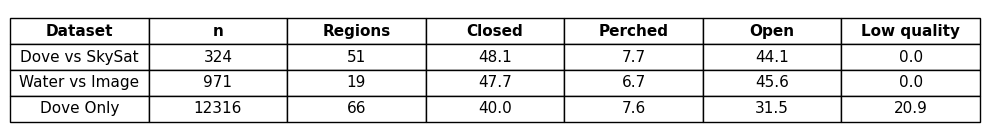

In [43]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SAVE_DIR.mkdir(parents=True, exist_ok=True)

LABELS_CSV = Path("/Volumes/x10pro/estuary/labeling/dove_split_by_region/labels.csv")


def remap_label(x):
    x = str(x).strip().lower()
    mapping = {
        "closed": "closed",
        "perched open": "perched",
        "perched": "perched",
        "open": "open",
        "unsure": "low quality",
        "low quality": "low quality",
    }
    return mapping.get(x, x)


def summarize_percentages(name, df, label_col):
    s = df[label_col].dropna().map(remap_label)

    frac = s.value_counts(normalize=True) * 100

    return {
        "Dataset": name,
        "n": len(s),
        "Regions": df["region"].nunique() if "region" in df else None,
        "Closed": round(frac.get("closed", 0), 1),
        "Perched": round(frac.get("perched", 0), 1),
        "Open": round(frac.get("open", 0), 1),
        "Low quality": round(frac.get("low quality", 0), 1),
    }


# -----------------------
# Load datasets
# -----------------------

rows = [
    summarize_percentages("Dove vs SkySat", d_ss_pairs, "label_ss"),
    summarize_percentages("Water vs Image", dd_pairs, "label_water"),
    summarize_percentages("Dove Only", d_df, "label"),
]

table = pd.DataFrame(rows)

print("\nClass distribution table\n")
print(table.to_markdown(index=False))

# Save CSV
table.to_csv(SAVE_DIR / "class_distribution_table.csv", index=False)

# Save LaTeX
with open(SAVE_DIR / "class_distribution_table.tex", "w") as f:
    f.write(table.to_latex(index=False, float_format="%.1f"))

# -----------------------
# Save PNG for Google Docs
# -----------------------

fig_h = 0.5 * len(table)

fig, ax = plt.subplots(figsize=(10, fig_h))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    colLabels=table.columns,
    loc="center",
    cellLoc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig(SAVE_DIR / "class_distribution_table.png", dpi=300, bbox_inches="tight")
plt.show()

Accuracy 3 class 75.6
Perch F1 0.367


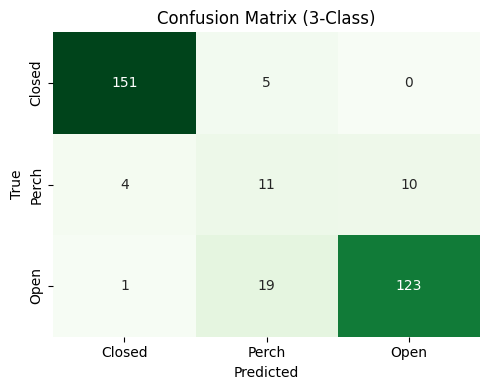

Accuracy Open/Closed 96.9


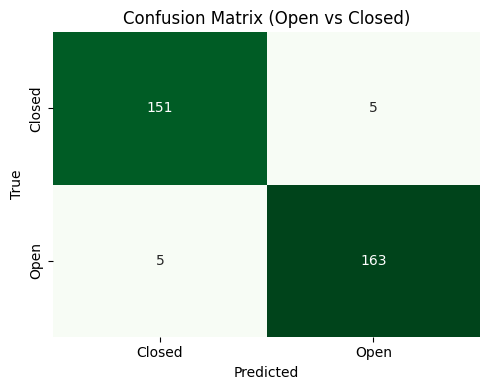

Accuracy No Perch 99.6
Either set perched 15.1 %


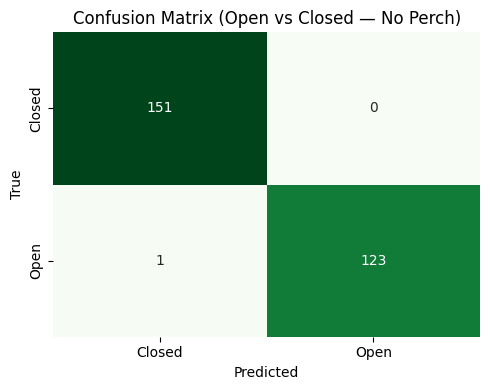

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------
# 3-CLASS CONFUSION MATRIX
# -------------------------------------------------------

labels = ["closed", "perched open", "open"]
disp_labels = ["Closed", "Perch", "Open"]

y_true = np.array([labels.index(l) for l in d_ss_pairs.label_ss])
y_pred = np.array([labels.index(l) for l in d_ss_pairs.label_dd])

print("Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Perch F1", round(f1_score(y_true == 1, y_pred == 1), 3))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=disp_labels,
    yticklabels=disp_labels,
    cbar=False,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (3-Class)")

plt.tight_layout()
plt.savefig(SAVE_DIR / "cm_3class_dove_ss.png", dpi=300)
plt.show()


# -------------------------------------------------------
# BINARY OPEN / CLOSED
# -------------------------------------------------------

LABELS = ["Closed", "Open"]

y_true = np.array([int("open" in l) for l in d_ss_pairs.label_ss])
y_pred = np.array([int("open" in l) for l in d_ss_pairs.label_dd])

print("Accuracy Open/Closed", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens", xticklabels=LABELS, yticklabels=LABELS, cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Open vs Closed)")

plt.tight_layout()
plt.savefig(SAVE_DIR / "cm_open_closed_dove_ss.png", dpi=300)
plt.show()


# -------------------------------------------------------
# BINARY OPEN / CLOSED (NO PERCH ROWS)
# -------------------------------------------------------

pairs = [
    (l, p)
    for l, p in zip(d_ss_pairs.label_ss, d_ss_pairs.label_dd)
    if "perch" not in l and "perch" not in p
]

y_true = np.array([int("open" in l) for l, _ in pairs])
y_pred = np.array([int("open" in p) for _, p in pairs])

print("Accuracy No Perch", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Either set perched", round(100 - 100 * len(y_true) / len(d_ss_pairs), 1), "%")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens", xticklabels=LABELS, yticklabels=LABELS, cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Open vs Closed — No Perch)")

plt.tight_layout()
plt.savefig(SAVE_DIR / "cm_no_perch_dove_ss.png", dpi=300)
plt.show()

In [48]:
# inspect = pd.concat([
#     d_ss_pairs[(d_ss_pairs.label_ss == "closed") & (d_ss_pairs.label_dd == "open")],
#     d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "closed")]
# ])
inspect = d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "closed")]
inspect_iter = inspect.iterrows()

ss_dd_save_dir = SAVE_DIR / "ss_dd_examples"
ss_dd_save_dir.mkdir(exist_ok=True, parents=True)

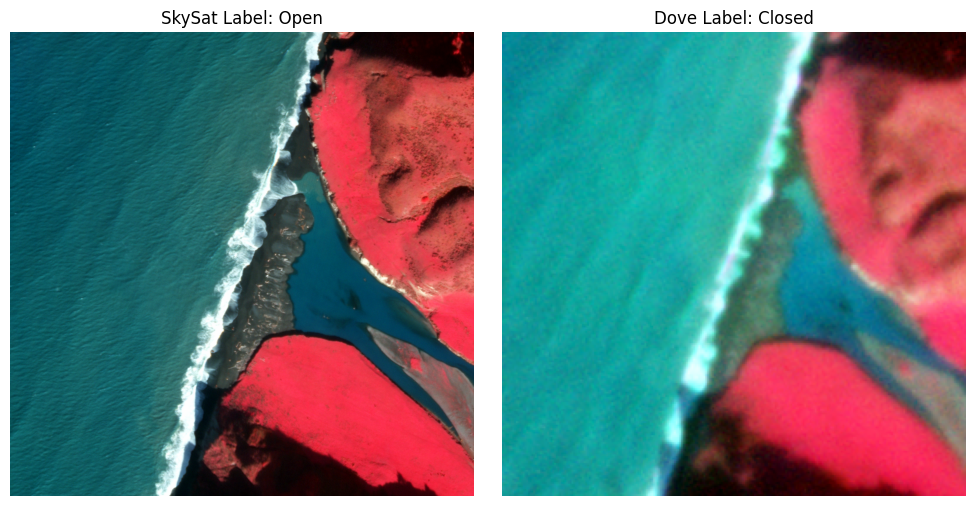

In [49]:
inspect_row(inspect_iter, "_ss", "_dd", "SkySat", "Dove", ss_dd_save_dir)


Results Table

| dataset        | task                   |   Balanced Accuracy |   Perch F1 |   Perch Removed (%) |
|:---------------|:-----------------------|--------------------:|-----------:|--------------------:|
| SkySat vs Dove | 3-class                |               0.756 |      0.367 |               nan   |
| SkySat vs Dove | open/closed            |               0.969 |    nan     |               nan   |
| SkySat vs Dove | open/closed (no perch) |               0.996 |    nan     |                15.1 |
| Water vs Image | 3-class                |               0.816 |      0.579 |               nan   |
| Water vs Image | open/closed            |               0.985 |    nan     |               nan   |
| Water vs Image | open/closed (no perch) |               0.998 |    nan     |                 7.8 |


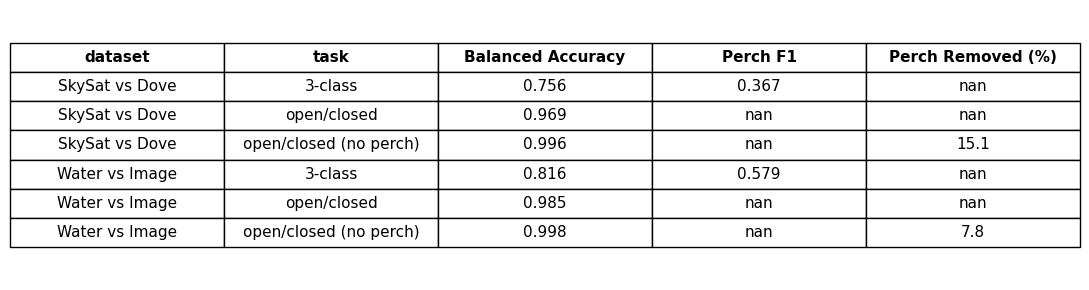

In [41]:
rows = []

# -----------------------------
# SS vs DD (3-class)
# -----------------------------
labels = ["closed", "perched open", "open"]
y_true = np.array([labels.index(l) for l in d_ss_pairs.label_ss])
y_pred = np.array([labels.index(l) for l in d_ss_pairs.label_dd])

rows.append(
    {
        "dataset": "SkySat vs Dove",
        "task": "3-class",
        "Balanced Accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "Perch F1": round(f1_score(y_true == 1, y_pred == 1), 3),
    }
)

# -----------------------------
# SS vs DD (binary)
# -----------------------------
y_true = np.array([int("open" in l) for l in d_ss_pairs.label_ss])
y_pred = np.array([int("open" in l) for l in d_ss_pairs.label_dd])

rows.append(
    {
        "dataset": "SkySat vs Dove",
        "task": "open/closed",
        "Balanced Accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "Perch F1": None,
    }
)

# -----------------------------
# SS vs DD (binary no perch)
# -----------------------------
pairs = [
    (l, p)
    for l, p in zip(d_ss_pairs.label_ss, d_ss_pairs.label_dd)
    if "perch" not in l and "perch" not in p
]

y_true = np.array([int("open" in l) for l, _ in pairs])
y_pred = np.array([int("open" in p) for _, p in pairs])

rows.append(
    {
        "dataset": "SkySat vs Dove",
        "task": "open/closed (no perch)",
        "Balanced Accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "Perch F1": None,
        "Perch Removed (%)": round(100 - 100 * len(y_true) / len(d_ss_pairs), 1),
    }
)

# -----------------------------
# WATER vs IMG (3-class)
# -----------------------------
labels = ["closed", "perched open", "open"]
y_true = np.array([labels.index(l) for l in dd_pairs.label_water])
y_pred = np.array([labels.index(l) for l in dd_pairs.label_img])

rows.append(
    {
        "dataset": "Water vs Image",
        "task": "3-class",
        "Balanced Accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "Perch F1": round(f1_score(y_true == 1, y_pred == 1), 3),
    }
)

# -----------------------------
# WATER vs IMG (binary)
# -----------------------------
y_true = np.array([int("open" in str(l).lower()) for l in dd_pairs.label_water])
y_pred = np.array([int("open" in str(l).lower()) for l in dd_pairs.label_img])

rows.append(
    {
        "dataset": "Water vs Image",
        "task": "open/closed",
        "Balanced Accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "Perch F1": None,
    }
)

# -----------------------------
# WATER vs IMG (binary no perch)
# -----------------------------
pairs = [
    (l, p)
    for l, p in zip(dd_pairs.label_water, dd_pairs.label_img)
    if "perch" not in str(l).lower() and "perch" not in str(p).lower()
]

y_true = np.array([int("open" in str(l).lower()) for l, _ in pairs])
y_pred = np.array([int("open" in str(p).lower()) for _, p in pairs])

rows.append(
    {
        "dataset": "Water vs Image",
        "task": "open/closed (no perch)",
        "Balanced Accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "Perch F1": None,
        "Perch Removed (%)": round(100 - 100 * len(y_true) / len(dd_pairs), 1),
    }
)

# -----------------------------
# Build Table
# -----------------------------
table = pd.DataFrame(rows)

print("\nResults Table\n")
print(table.to_markdown(index=False))

table.to_csv(SAVE_DIR / "model_results_summary.csv", index=False)

fig_h = 0.5 * len(table)

fig, ax = plt.subplots(figsize=(11, fig_h))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    colLabels=table.columns,
    loc="center",
    cellLoc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

fig.tight_layout()
fig.savefig(SAVE_DIR / "model_results_summary.png", dpi=300, bbox_inches="tight")
plt.show()

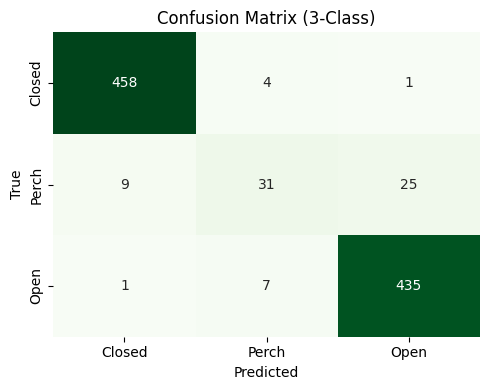

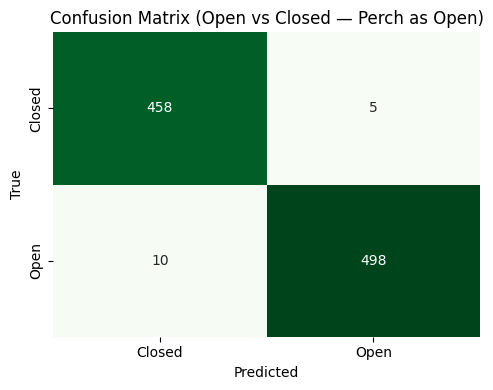

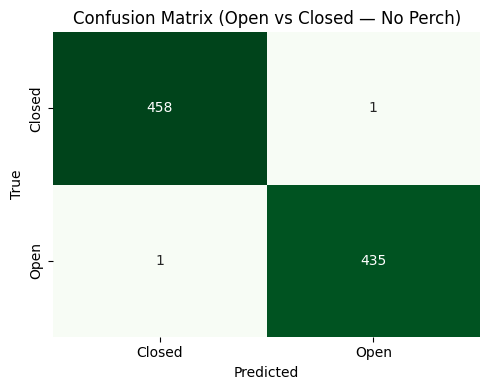

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3-class (Closed / Perch / Open)
# -----------------------------
labels = ["closed", "perched open", "open"]
disp_labels = ["Closed", "Perch", "Open"]  # <- requested naming

y_true = np.array([labels.index(l) for l in dd_pairs.label_water])
y_pred = np.array([labels.index(l) for l in dd_pairs.label_img])

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=disp_labels,
    yticklabels=disp_labels,
    cbar=False,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (3-Class)")
plt.tight_layout()
plt.savefig(SAVE_DIR / "cm_3class_dove_water.png", dpi=300)
plt.show()


# -----------------------------
# Binary (Closed / Open) — treat Perch as Open (your old behavior)
# -----------------------------
bin_labels = ["Closed", "Open"]

y_true = np.array([int("open" in str(l).lower()) for l in dd_pairs.label_water], dtype=int)
y_pred = np.array([int("open" in str(l).lower()) for l in dd_pairs.label_img], dtype=int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=bin_labels,
    yticklabels=bin_labels,
    cbar=False,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Open vs Closed — Perch as Open)")
plt.tight_layout()
plt.savefig(SAVE_DIR / "cm_open_closed_dove_water.png", dpi=300)
plt.show()


# -----------------------------
# Binary (Closed / Open) — drop any row where either label is Perch
# -----------------------------
pairs = [
    (l, p)
    for l, p in zip(dd_pairs.label_water, dd_pairs.label_img)
    if "perch" not in str(l).lower() and "perch" not in str(p).lower()
]

y_true = np.array([int("open" in str(l).lower()) for l, _ in pairs], dtype=int)
y_pred = np.array([int("open" in str(p).lower()) for _, p in pairs], dtype=int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=bin_labels,
    yticklabels=bin_labels,
    cbar=False,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Open vs Closed — No Perch)")
plt.tight_layout()
plt.savefig(SAVE_DIR / "cm_no_perch_dove_water.png", dpi=300)
plt.show()

In [35]:
# inspect_d = pd.concat(
#     [
#         dd_pairs[(dd_pairs.label_water == "closed") & (dd_pairs.label_img == "open")],
#         dd_pairs[(dd_pairs.label_water == "open") & (dd_pairs.label_img == "closed")],
#     ]
# )
inspect_d = dd_pairs[(dd_pairs.label_water == "open") & (dd_pairs.label_img == "closed")]
inspect_d_iter = inspect_d.iterrows()

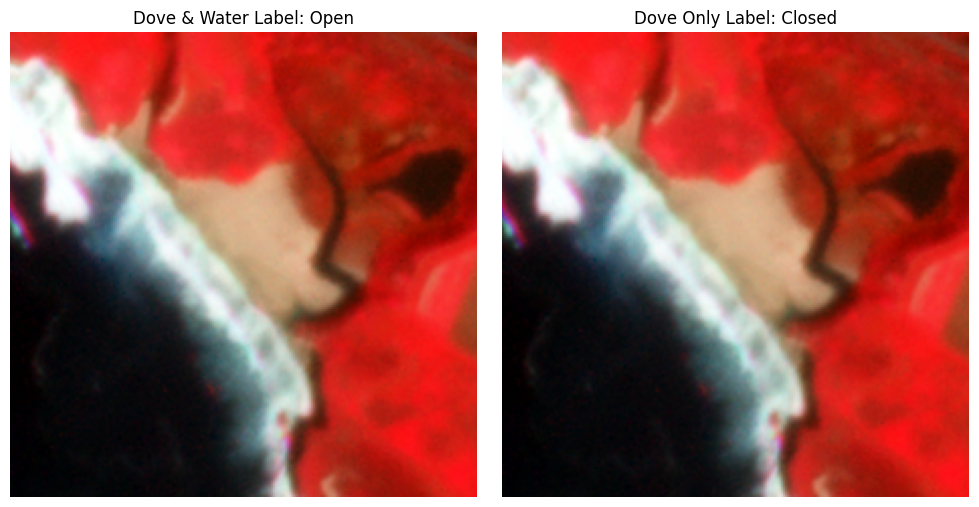

In [36]:
inspect_row(inspect_d_iter, "_water", "_img", title_left="Dove & Water", title_right="Dove Only")

In [37]:
non_merged_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/all_regions_timeseries_preds.csv"
)
len(non_merged_preds), (non_merged_preds.y_pred_unsure != 1).sum().item()

(98317, 92487)

In [38]:
train_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/train_preds.csv"
)
len(train_preds), (train_preds.y_true != -1).sum().item()

(12316, 9742)

In [39]:
preds_all_orig = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260305-095554/merged_all_regions_timeseries_preds.csv"
)

preds_all_orig["acquired"] = pd.to_datetime(preds_all_orig["acquired"], errors="coerce", utc=True)
preds_all_orig["date"] = preds_all_orig.acquired.dt.date
preds_all_orig["month"] = preds_all_orig.acquired.dt.month
preds_all_orig["year"] = preds_all_orig.acquired.dt.year
preds_all = preds_all_orig.copy()
preds_all = (
    preds_all[(preds_all.region.isin(gdf.index)) & (preds_all.y_pred_unsure != 1)]
    .copy()
    .sort_values(by=["region", "acquired"])
    .reset_index(drop=True)
)

preds_all.head(3)

,region,date,y_true,y_true_unsure,acquired,source_tif,y_pred_unsure,y_pred,p_closed,p_open,month,year
0,11,2017-02-01,1,0,2017-02-01 17:46:04+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.013752,0.986248,2,2017
1,11,2017-02-25,1,0,2017-02-25 17:46:40+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000013,0.999987,2,2017
2,11,2017-03-03,1,0,2017-03-03 17:47:32+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.000008,0.999992,3,2017


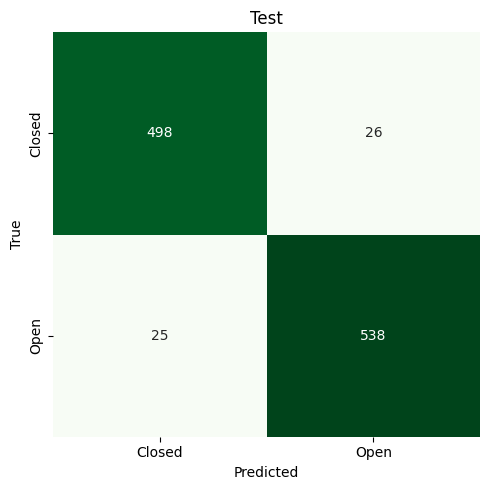

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize=(5, 5))

preds_test = train_preds[(train_preds.year == 2025) & (train_preds.y_true >= 0)]
preds_test_val = train_preds[
    ((train_preds.year == 2025) | (train_preds.year == 2021)) & (train_preds.y_true >= 0)
]

disp_labels = ["Closed", "Open"]


# -----------------------
# TEST
# -----------------------
y_true = preds_test.y_true
y_pred = preds_test.y_pred

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=disp_labels,
    yticklabels=disp_labels,
    cbar=False,
    ax=ax,
)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test")

fig.tight_layout()
plt.savefig(SAVE_DIR / "cm_test.png")
plt.show()

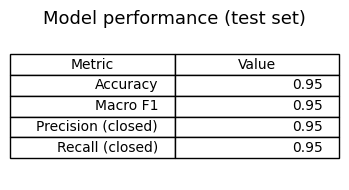

,Metric,Value
0,Accuracy,0.95
1,Macro F1,0.95
2,Precision (closed),0.95
3,Recall (closed),0.95


In [25]:
# TABLE 1 — Overall model performance (TEST SET ONLY, ONE TABLE)
# (no 3-class block; just the binary closed-vs-not-closed metrics)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


def _clean_xy(df: pd.DataFrame):
    df = df[(df["y_true"] >= 0) & (df["y_pred"] >= 0)].copy()
    return df["y_true"].to_numpy(), df["y_pred"].to_numpy()


def _to_closed_vs_not(y):
    # closed = class 0
    return (np.asarray(y) == 0).astype(int)  # 1=closed, 0=not-closed


def make_table_test_binary(preds_test: pd.DataFrame) -> pd.DataFrame:
    y_true, y_pred = _clean_xy(preds_test)

    y_true2 = _to_closed_vs_not(y_true)
    y_pred2 = _to_closed_vs_not(y_pred)

    table = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Macro F1",
                "Precision (closed)",
                "Recall (closed)",
            ],
            "Value": [
                accuracy_score(y_true2, y_pred2),
                f1_score(y_true2, y_pred2, average="macro", labels=[0, 1], zero_division=1),
                precision_score(y_true2, y_pred2, pos_label=1, zero_division=1),
                recall_score(y_true2, y_pred2, pos_label=1, zero_division=1),
            ],
        }
    )
    table["Value"] = table["Value"].astype(float).round(2)
    return table


def make_figure_table(table: pd.DataFrame, title="Model performance (test set)", savepath=None):
    fig, ax = plt.subplots(figsize=(3.6, 2.0))
    ax.axis("off")

    t = ax.table(
        cellText=table.values,
        colLabels=table.columns,
        loc="center",
    )

    t.auto_set_font_size(False)
    t.set_fontsize(10)
    t.scale(1.2, 1.3)

    plt.title(title, fontsize=13)
    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


# --- run ---
table1 = make_table_test_binary(preds_test)
fig = make_figure_table(
    table1,
    title="Model performance (test set)",
    savepath=SAVE_DIR / "results_table_1.png",
)

table1

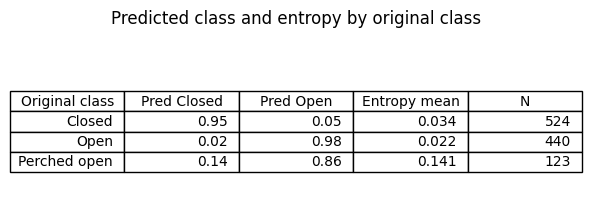

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# Binary entropy
# -----------------------------
p = preds_test["p_open"].values
entropy = -(p * np.log(p + 1e-12) + (1 - p) * np.log(1 - p + 1e-12))

preds_test = preds_test.copy()
preds_test["entropy"] = entropy


rows = []

for label, df in preds_test.groupby("orig_label"):
    pred_closed_rate = (df["y_pred"] == 0).mean()
    pred_open_rate = (df["y_pred"] == 1).mean()

    q1 = df["entropy"].quantile(0.25)
    q3 = df["entropy"].quantile(0.75)

    rows.append(
        {
            "Original class": label.capitalize(),
            "Pred Closed": round(pred_closed_rate, 2),
            "Pred Open": round(pred_open_rate, 2),
            "Entropy mean": round(df["entropy"].mean(), 3),
            "N": len(df),
        }
    )

table2 = pd.DataFrame(rows)

# -----------------------------
# Plot table
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 2.2))
ax.axis("off")

t = ax.table(cellText=table2.values, colLabels=table2.columns, loc="center")

t.auto_set_font_size(False)
t.set_fontsize(10)
t.scale(1.2, 1.3)

fig.suptitle("Predicted class and entropy by original class")
fig.tight_layout()

fig.savefig(SAVE_DIR / "results_table_2.png", dpi=300)
plt.show()

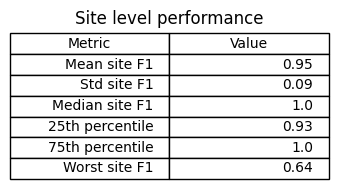

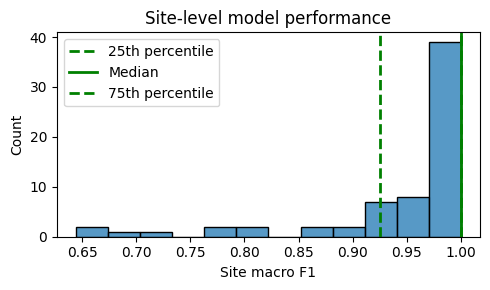

In [27]:
import seaborn as sns
from sklearn.metrics import f1_score


def make_table3_region_performance(preds_test):
    df = preds_test[(preds_test.y_true >= 0) & (preds_test.y_pred >= 0)].copy()

    region_f1 = (
        df.groupby("region")
        .apply(
            lambda g: f1_score(
                g.y_true, g.y_pred, average="macro", labels=[0, 1, 2], zero_division=1
            ),
            include_groups=False,
        )
        .rename("f1")
    )

    q25 = region_f1.quantile(0.25)
    q75 = region_f1.quantile(0.75)

    table3 = pd.DataFrame(
        {
            "Metric": [
                "Mean site F1",
                "Std site F1",
                "Median site F1",
                "25th percentile",
                "75th percentile",
                "Worst site F1",
            ],
            "Value": [
                round(region_f1.mean(), 2),
                round(region_f1.std(), 2),
                round(region_f1.median(), 2),
                round(q25, 2),
                round(q75, 2),
                round(region_f1.min(), 2),
            ],
        }
    )

    return table3, region_f1, q25, q75


table3, region_f1, q25, q75 = make_table3_region_performance(preds_test)

fig, ax = plt.subplots(figsize=(3.5, 2))

ax.axis("off")

t = ax.table(cellText=table3.values, colLabels=table3.columns, loc="center")

t.auto_set_font_size(False)
t.set_fontsize(10)
t.scale(1.2, 1.3)

plt.title("Site level performance")
plt.tight_layout()
fig.savefig(SAVE_DIR / "results_table_3.png")
plt.show()

plt.figure(figsize=(5, 3))

sns.histplot(region_f1, bins=12)

plt.axvline(q25, linestyle="--", linewidth=2, label="25th percentile", color="green")
plt.axvline(region_f1.median(), linestyle="-", linewidth=2, label="Median", color="green")
plt.axvline(q75, linestyle="--", linewidth=2, label="75th percentile", color="green")

plt.xlabel("Site macro F1")
plt.ylabel("Count")
plt.title("Site-level model performance")

plt.legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / "site_level_f1.png")
plt.show()

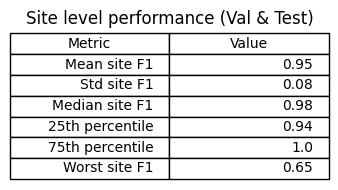

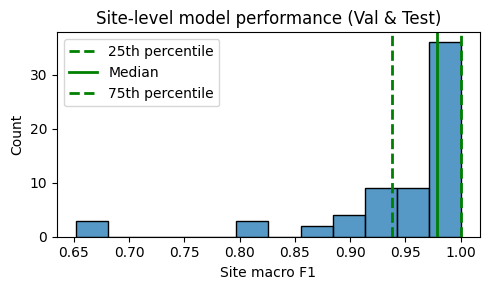

In [28]:
table3_test_val, region_f1_test_val, q25_test_val, q75_test_val = make_table3_region_performance(
    preds_test_val
)

fig, ax = plt.subplots(figsize=(3.5, 2))

ax.axis("off")

t = ax.table(cellText=table3_test_val.values, colLabels=table3_test_val.columns, loc="center")

t.auto_set_font_size(False)
t.set_fontsize(10)
t.scale(1.2, 1.3)

plt.title("Site level performance (Val & Test)")
plt.tight_layout()
fig.savefig(SAVE_DIR / "results_table_3_test_val.png")
plt.show()

plt.figure(figsize=(5, 3))

sns.histplot(region_f1_test_val, bins=12)

plt.axvline(q25_test_val, linestyle="--", linewidth=2, label="25th percentile", color="green")
plt.axvline(region_f1_test_val.median(), linestyle="-", linewidth=2, label="Median", color="green")
plt.axvline(q75_test_val, linestyle="--", linewidth=2, label="75th percentile", color="green")

plt.xlabel("Site macro F1")
plt.ylabel("Count")
plt.title("Site-level model performance (Val & Test)")

plt.legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / "site_level_f1_test_val.png")
plt.show()

In [29]:
region_f1_test_val = (
    preds_test_val.groupby("region")
    .apply(
        lambda g: f1_score(
            g.y_true, g.y_pred, average="macro", labels=[0, 1, 2], zero_division=1.0
        ),
        include_groups=False,
    )
    .rename("f1")
    .sort_values()
)

mid = len(region_f1_test_val) // 2
print(
    region_f1_test_val.index[0].item(),
    region_f1_test_val.index[mid].item(),
    region_f1_test_val.index[-1].item(),
)

79 88 11


In [30]:
region_f1_test_val[region_f1_test_val < 0.9].round(3)

region
79       0.652
2147     0.655
12103    0.659
85       0.805
38       0.817
32       0.821
93       0.882
18       0.883
81       0.889
64       0.891
Name: f1, dtype: float64

In [31]:
preds_test_val[
    preds_test_val.region.isin(region_f1_test_val[region_f1_test_val < 0.9].index)
].groupby("region").p_open.mean()

region
18       0.044687
32       0.053134
38       0.197603
64       0.665491
79       0.980738
81       0.430505
85       0.357956
93       0.536506
2147     0.005516
12103    0.999934
Name: p_open, dtype: float64

<Axes: xlabel='accuracy', ylabel='f1'>

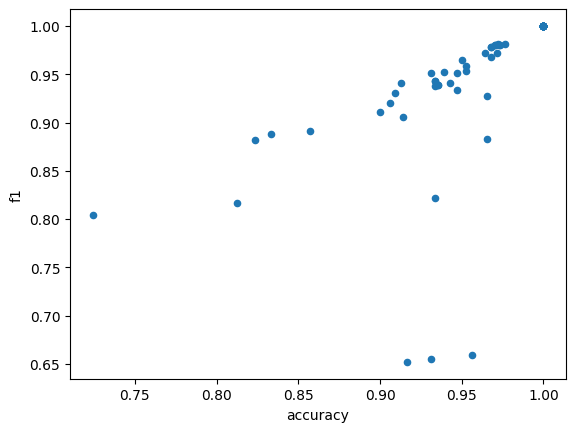

In [32]:
def acc(rdf):
    return (rdf.y_pred == rdf.y_true).sum() / len(rdf)


low_f1_sites = region_f1_test_val[region_f1_test_val < 0.9].index
site_acc = (
    preds_test_val.groupby("region")
    .apply(acc, include_groups=False)
    .sort_values()
    .rename("accuracy")
)

pd.merge(site_acc, region_f1_test_val.rename("f1"), left_index=True, right_index=True).plot.scatter(
    "accuracy", "f1"
)

In [33]:
sum(site_acc < 0.9)

5

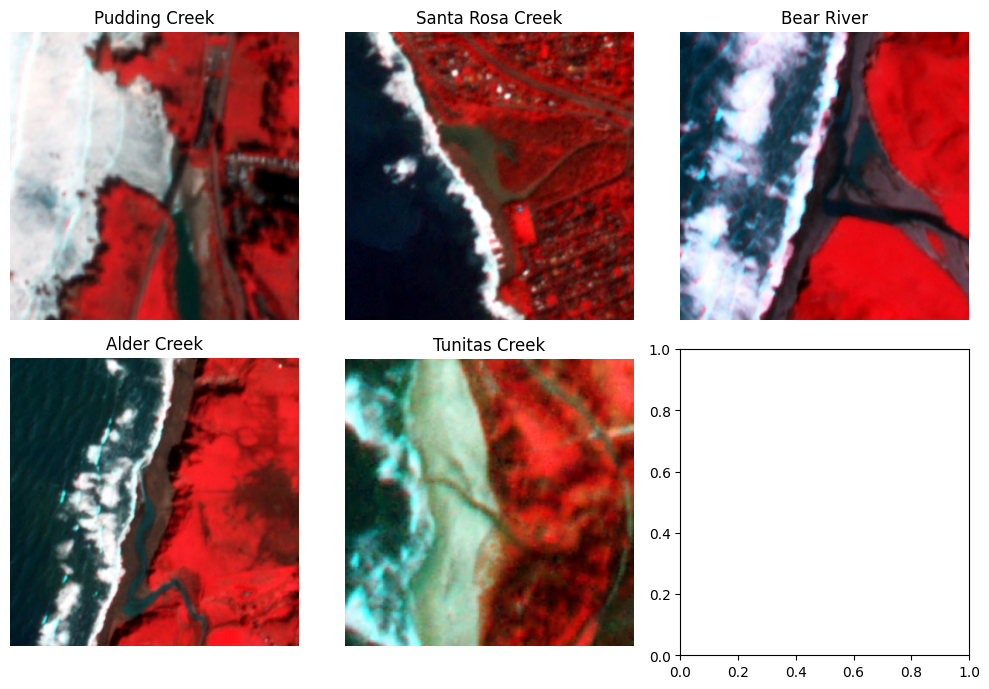

In [36]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))

regions = site_acc[site_acc < 0.9].index

for ax, region in zip(axes.flatten(), regions):
    ax.axis("off")
    pth = d_df[(d_df.region == region) & (d_df.label == "open")].iloc[0].source_tif

    with rasterio.open(pth) as src:
        data = src.read().astype(np.float32)
        nodata = src.read(1, masked=True).mask
        img = false_color(data, nodata)

    ax.imshow(img)
    ax.set_title(gdf.loc[region].Estuary_Name)

fig.tight_layout()
plt.show()

In [37]:
region_f1 = (
    preds_test.groupby("region")
    .apply(
        lambda g: f1_score(
            g.y_true, g.y_pred, average="macro", labels=[0, 1, 2], zero_division=1.0
        ),
        include_groups=False,
    )
    .rename("f1")
    .sort_values()
)

mid = len(region_f1) // 2
print(region_f1.index[0].item(), region_f1.index[mid].item(), region_f1.index[-1].item())

2147 35 11


In [38]:
preds_test.region.value_counts().describe()

count    66.000000
mean     16.469697
std       3.268590
min      10.000000
25%      14.000000
50%      16.000000
75%      19.000000
max      25.000000
Name: count, dtype: float64

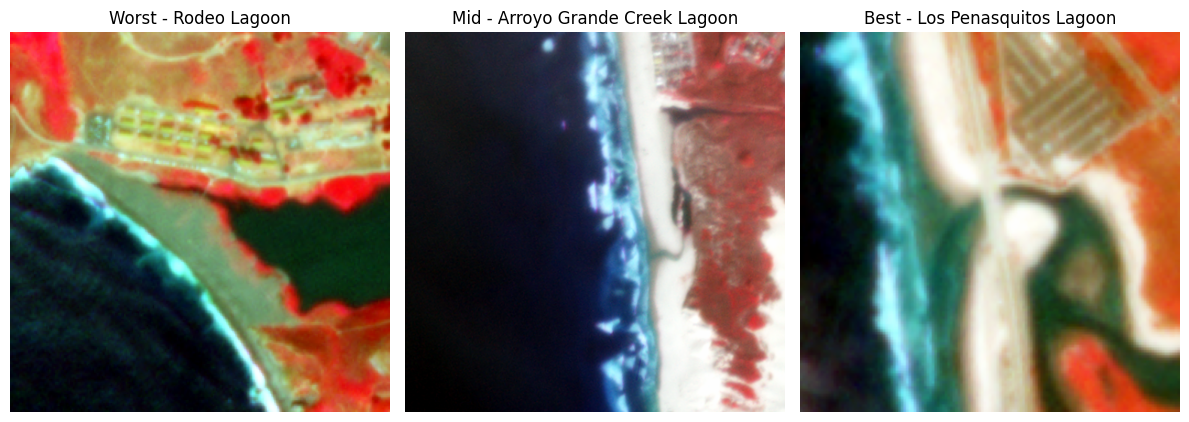

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4.5))
for ax in axes:
    ax.axis("off")

pth0 = "/Volumes/x10pro/estuary/sat_data/superdove/results/2025/9/2147/files/20250906_193020_46_24fd_3B_AnalyticMS_SR_8b_clip.tif"

with rasterio.open(pth0) as src:
    data = src.read().astype(np.float32)
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)

axes[0].imshow(img)
axes[0].set_title(f"Worst - {gdf.loc[2147].Estuary_Name}")

pth0 = "/Volumes/x10pro/estuary/sat_data/superdove/results/2025/2/34/files/20250201_190236_84_24e6_3B_AnalyticMS_SR_8b_clip.tif"

with rasterio.open(pth0) as src:
    data = src.read().astype(np.float32)
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)

axes[1].imshow(img)
axes[1].set_title(f"Mid - {gdf.loc[34].Estuary_Name}")

pth0 = "/Volumes/x10pro/estuary/sat_data/superdove/results/2025/9/11/files/20250904_185906_31_24ee_3B_AnalyticMS_SR_8b_clip.tif"

with rasterio.open(pth0) as src:
    data = src.read().astype(np.float32)
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)

axes[2].imshow(img)
axes[2].set_title(f"Best - {gdf.loc[11].Estuary_Name}")

fig.tight_layout()
fig.savefig(SAVE_DIR / "example_site_imgs.png")
plt.show()


Results Table

| Dataset         |     N |   Low Quality (%) |   Closed (%) |   Open (%) |
|:----------------|------:|------------------:|-------------:|-----------:|
| All Predictions | 98317 |               5.9 |         50.6 |       43.4 |
| Merged Same-Day | 74324 |               5.4 |         50.8 |       43.7 |


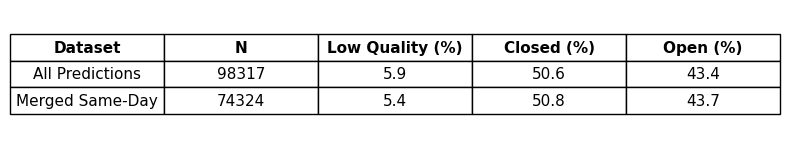

In [40]:
import numpy as np
import pandas as pd

disp_labels = ["Closed", "Open"]
all_classes = ["Low Quality"] + disp_labels


def summarize_dataset(df: pd.DataFrame, name: str) -> dict:
    df = df.copy()

    # Map predictions to display label
    df["label"] = np.where(
        df["y_pred_unsure"], "Low Quality", df["y_pred"].map(dict(enumerate(disp_labels)))
    )

    total = len(df)
    counts = df["label"].value_counts().reindex(all_classes, fill_value=0)

    row = {"Dataset": name, "N": total}

    for cls in all_classes:
        c = counts[cls]
        pct = 100 * c / total if total > 0 else 0
        # row[f"{cls} (n)"] = c
        row[f"{cls} (%)"] = round(pct, 1)

    return row


table = pd.DataFrame(
    [
        summarize_dataset(non_merged_preds, "All Predictions"),
        summarize_dataset(preds_all_orig, "Merged Same-Day"),
    ]
)

# -----------------------------
# Build Table
# -----------------------------
print("\nResults Table\n")
print(table.to_markdown(index=False))

table.to_csv(SAVE_DIR / "timeseries_results.csv", index=False)

fig_h = 0.6 + 0.5 * len(table)

fig, ax = plt.subplots(figsize=(8, fig_h))
ax.axis("off")

tbl = ax.table(
    cellText=table.values,
    colLabels=table.columns,
    loc="center",
    cellLoc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig(SAVE_DIR / "timeseries_results.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
len(preds_all)

70278

In [42]:
preds_all.region.value_counts().describe()

count      66.000000
mean     1064.818182
std       150.154373
min       663.000000
25%      1011.250000
50%      1073.000000
75%      1182.750000
max      1312.000000
Name: count, dtype: float64

In [43]:
pct_by_region = (
    preds_all.groupby("region")["y_pred"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={0: "closed_pct", 1: "open_pct"})
    .sort_values("open_pct")
)

pct_by_region.round(3)

y_pred,closed_pct,open_pct
region,,
65,0.996,0.004
2147,0.990,0.010
16,0.943,0.057
29,0.943,0.057
95,0.928,0.072
...,...,...
14054,0.092,0.908
11,0.065,0.935
13099,0.011,0.989


In [44]:
pct_by_region.closed_pct.describe().round(3)

count    66.000
mean      0.541
std       0.285
min       0.000
25%       0.323
50%       0.601
75%       0.773
max       0.996
Name: closed_pct, dtype: float64

In [45]:
pct_by_region[pct_by_region.closed_pct < 0.01]

y_pred,closed_pct,open_pct
region,,
79,0.0,1.0
12103,0.0,1.0


In [46]:
ca = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_geo.geojson")
pmep_points = gpd.read_file("/Volumes/x10pro/estuary/geos/PMEP_Estuary_Points_V1_3.gdb/").to_crs(
    ca.crs
)

# Goleta Slough too close to San Pedro Creek, we see both!
pmep_points = pmep_points[pmep_points.PMEP_EstuaryID != 4003].copy()

pmep_points = pmep_points[pmep_points.intersects(ca.iloc[0].geometry)].copy()
print(len(pmep_points))
pmep_points.head()

189


/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,geometry
253,2087,Smith River,PMEP,Riverine Estuary,"Washington, Oregon, Northern California Coast",120.0,481.289637,2087_Smith River,POINT Z (-124.18315 41.91363 0.00013)
254,2088,Lake Earl,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",121.0,1609.386192,2088_Lake Earl,POINT Z (-124.19721 41.82226 0.00013)
255,2089,Pebble Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",122.0,14.537437,2089_Pebble Beach,POINT Z (-124.22426 41.76496 0.00013)
256,2090,Crescent City Harbor,PMEP,Embayment/Bay,"Washington, Oregon, Northern California Coast",123.0,188.965914,2090_Crescent City Harbor,POINT Z (-124.19052 41.74395 0.00013)
257,2091,NC9 Cresent Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",124.0,7.051772,2091_NC9 Cresent Beach,POINT Z (-124.15027 41.72553 0.00013)


In [48]:
gdf_plot = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
gdf_plot = gdf_plot[gdf_plot.skipped == False].copy()
gdf_plot["in_dataset"] = True

In [49]:
joined = pmep_points.join(
    gdf_plot[
        ["PMEP_EstuaryID", "in_dataset", "Site name", "point_geom_lat", "point_geom_long"]
    ].set_index("PMEP_EstuaryID"),
    on="PMEP_EstuaryID",
    how="outer",
)

# 1. fill in_dataset
joined["in_dataset"] = joined["in_dataset"].fillna(False)

# 2. build geometry for rows missing PMEP_EstuaryID
mask = joined["PMEP_EstuaryID"].isna()

joined.loc[mask, "CMECS_Class"] = "Lagoonal Estuary"

joined.loc[mask, "geometry"] = gpd.points_from_xy(
    joined.loc[mask, "point_geom_long"], joined.loc[mask, "point_geom_lat"]
)

joined.loc[mask, "Estuary_Name"] = joined.loc[mask, "Site name"]

joined.loc[mask, "Estuary_Hectares"] = 50.0

# 3. drop temporary columns
joined = joined.drop(columns=["point_geom_lat", "point_geom_long", "Site name"])

# 4. ensure it's still a GeoDataFrame
joined = gpd.GeoDataFrame(joined, geometry="geometry", crs=pmep_points.crs)

joined.head()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_81601/118060239.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  joined["in_dataset"] = joined["in_dataset"].fillna(False)


,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,geometry,in_dataset
253.0,2087.0,Smith River,PMEP,Riverine Estuary,"Washington, Oregon, Northern California Coast",120.0,481.289637,2087_Smith River,POINT Z (-124.18315 41.91363 0.00013),False
254.0,2088.0,Lake Earl,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",121.0,1609.386192,2088_Lake Earl,POINT Z (-124.19721 41.82226 0.00013),True
255.0,2089.0,Pebble Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",122.0,14.537437,2089_Pebble Beach,POINT Z (-124.22426 41.76496 0.00013),False
256.0,2090.0,Crescent City Harbor,PMEP,Embayment/Bay,"Washington, Oregon, Northern California Coast",123.0,188.965914,2090_Crescent City Harbor,POINT Z (-124.19052 41.74395 0.00013),False
257.0,2091.0,NC9 Cresent Beach,PMEP,Lagoonal Estuary,"Washington, Oregon, Northern California Coast",124.0,7.051772,2091_NC9 Cresent Beach,POINT Z (-124.15027 41.72553 0.00013),False


In [50]:
# import folium
# import numpy as np

# f = pmep_points[pmep_points.CMECS_Class != "Embayment/Bay"]

# # Center map
# m = folium.Map(
#     location=[f.geometry.y.mean(), f.geometry.x.mean()],
#     zoom_start=6,
#     tiles="CartoDB positron",
# )

# # --- Size scaling ---
# hectares = f["Estuary_Hectares"].fillna(0)

# min_r = 3
# max_r = 12

# scaled = np.sqrt(hectares)
# scaled = (scaled - scaled.min()) / (scaled.max() - scaled.min())
# radii = min_r + scaled * (max_r - min_r)

# # --- Color mapping ---
# classes = sorted(f["CMECS_Class"].dropna().unique())

# palette = [
#     "#1b9e77",
#     "#d95f02",
#     "#7570b3",
#     "#e7298a",
#     "#66a61e",
#     "#e6ab02",
#     "#a6761d",
#     "#666666",
# ]

# color_map = dict(zip(classes, palette[: len(classes)]))

# # --- Plot points ---
# for (_, row), r in zip(f.iterrows(), radii):
#     cls = row["CMECS_Class"]
#     color = color_map.get(cls, "#999999")

#     folium.CircleMarker(
#         location=[row.geometry.y, row.geometry.x],
#         radius=r,
#         color=color,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.7,
#         weight=1,
#         tooltip=f"""
#         <b>{row.get("Estuary_Name", "")}</b><br>
#         CMECS: {cls}<br>
#         Area: {row["Estuary_Hectares"]:.1f} ha
#         """,
#     ).add_to(m)

# # --- Legend ---
# legend_html = """
# <div style="
# position: fixed;
# bottom: 50px;
# left: 50px;
# width: 250px;
# background-color: white;
# border:2px solid grey;
# z-index:9999;
# font-size:14px;
# padding:10px;
# ">
# <b>CMECS Class</b><br>
# """

# for cls, color in color_map.items():
#     legend_html += f"""
#     <i style="background:{color};
#               width:12px;
#               height:12px;
#               display:inline-block;
#               margin-right:6px;"></i>{cls}<br>
#     """

# legend_html += "</div>"

# m.get_root().html.add_child(folium.Element(legend_html))

# m

/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


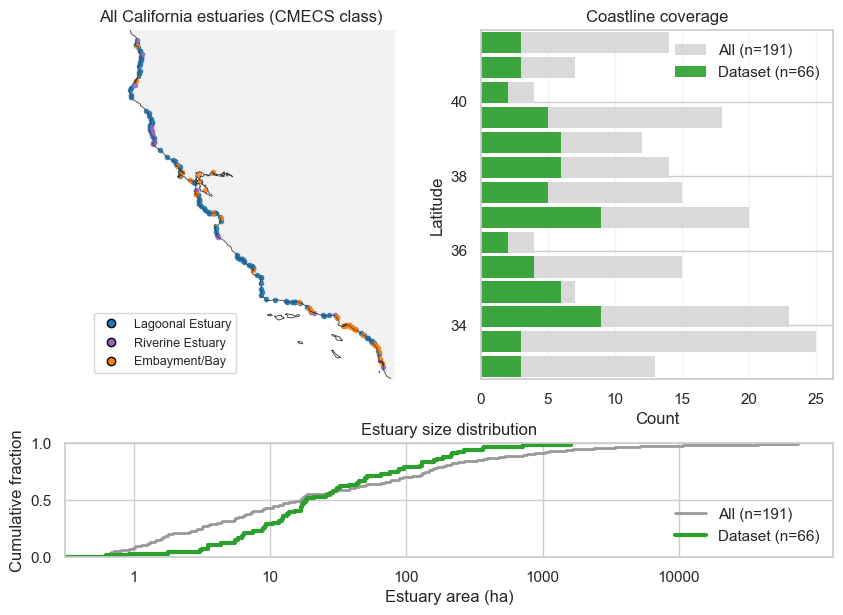

In [51]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D


def make_opening_figure(joined):
    # --- prep ---
    df = joined.copy()
    df = df[df.geometry.notna()].copy()
    df["in_dataset"] = df["in_dataset"].fillna(False).astype(bool)
    df["CMECS_Class"] = df["CMECS_Class"].fillna("Unknown")

    # Use lagoonal-only for strip+ECDF if you want (recommended for your story)
    # df_lag = df[df["CMECS_Class"] == "Lagoonal Estuary"].copy()
    df_lag = df

    sns.set_theme(style="whitegrid")

    # Map classes (keep legend manageable)
    classes = ["Lagoonal Estuary", "Riverine Estuary", "Embayment/Bay", "Unknown"]
    classes = [c for c in classes if (df["CMECS_Class"] == c).any()]

    palette = {
        "Lagoonal Estuary": "#1f77b4",  # blue
        "Riverine Estuary": "#9467bd",  # purple
        "Embayment/Bay": "#ff7f0e",  # orange
        "Unknown": "0.6",
    }

    COLOR_ALL = "0.6"
    COLOR_DS = "#2ca02c"

    # --- layout you requested ---
    fig = plt.figure(figsize=(8, 6.2))

    gs = fig.add_gridspec(
        nrows=3,
        ncols=2,
        height_ratios=[1.0, 1.0, 0.8],  # bottom row shorter (ECDF)
        width_ratios=[1.0, 1.0],  # right column narrower (strip)
        wspace=0.18,
        hspace=0.48,
    )

    ax_map = fig.add_subplot(gs[0:2, 0], projection=ccrs.PlateCarree())
    ax_ecdf = fig.add_subplot(gs[2, 0:2])
    ax_strip = fig.add_subplot(gs[0:2, 1])  # spans all rows

    # ----------------
    # Panel A: State map (ALL estuaries colored by CMECS)
    # ----------------
    minx, maxx = -125.6, -116.8
    miny, maxy = 32.2, 42.2
    proj = ccrs.PlateCarree()

    ax_map.set_extent([minx, maxx, miny, maxy], crs=proj)
    ax_map.add_feature(cfeature.LAND.with_scale("10m"), facecolor="0.95", edgecolor="none")
    ax_map.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
    ax_map.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6, color="0.25")
    ax_map.axis("off")
    ax_map.set_title("All California estuaries (CMECS class)", fontsize=12)

    for cls in classes:
        g = df[df["CMECS_Class"] == cls]
        if g.empty:
            continue
        ax_map.scatter(
            g.geometry.x,
            g.geometry.y,
            s=9,
            color=palette.get(cls, "0.6"),
            alpha=0.85,
            transform=proj,
            rasterized=True,
        )

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=palette.get(cls, "0.6"),
            markersize=6,
            label=cls,
        )
        for cls in classes
    ]
    ax_map.legend(handles=handles, loc="lower left", frameon=True, fontsize=9)

    # ----------------
    # Panel B: Coastline coverage (latitude histogram)
    # ----------------
    df_lag = df_lag[df_lag.geometry.notna()].copy()
    df_lag["lat"] = df_lag.geometry.y

    lat_all = df_lag["lat"].to_numpy()
    lat_ds = df_lag.loc[df_lag["in_dataset"], "lat"].to_numpy()

    # Choose number of latitude bins (10–16 usually looks good)
    n_bins = 14
    bins = np.linspace(lat_all.min(), lat_all.max(), n_bins + 1)

    # Horizontal bars are easier in a tall/narrow panel
    counts_all, _ = np.histogram(lat_all, bins=bins)
    counts_ds, _ = np.histogram(lat_ds, bins=bins)

    bin_mids = 0.5 * (bins[:-1] + bins[1:])
    bin_h = (bins[1] - bins[0]) * 0.85

    ax_strip.barh(
        bin_mids,
        counts_all,
        height=bin_h,
        color="0.85",
        edgecolor="none",
        label=f"All (n={len(lat_all)})",
    )

    ax_strip.barh(
        bin_mids,
        counts_ds,
        height=bin_h,
        color=COLOR_DS,
        edgecolor="none",
        alpha=0.9,
        label=f"Dataset (n={len(lat_ds)})",
    )

    ax_strip.set_ylabel("Latitude")
    ax_strip.set_xlabel("Count")
    ax_strip.set_title("Coastline coverage", fontsize=12)

    # Keep y-lims tight and nice
    ax_strip.set_ylim(lat_all.min(), lat_all.max())
    ax_strip.grid(axis="x", alpha=0.25)

    # Legend inside to avoid layout whitespace
    ax_strip.legend(loc="upper right", frameon=False)

    # ----------------
    # Panel C: ECDF size (ALL vs DATASET)
    # ----------------
    df_ecdf = df_lag[df_lag["Estuary_Hectares"].notna()].copy()

    sns.ecdfplot(
        data=df_ecdf,
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_ALL,
        lw=2,
        label=f"All (n={len(df_ecdf)})",
    )
    sns.ecdfplot(
        data=df_ecdf[df_ecdf["in_dataset"]],
        x="Estuary_Hectares",
        ax=ax_ecdf,
        color=COLOR_DS,
        lw=3,
        label=f"Dataset (n={df_ecdf['in_dataset'].sum()})",
    )

    ax_ecdf.set_xscale("log")
    ax_ecdf.set_xlabel("Estuary area (ha)")
    ax_ecdf.set_ylabel("Cumulative fraction")
    ax_ecdf.set_title("Estuary size distribution", fontsize=12)

    ticks = [1, 10, 100, 1000, 10000]
    ax_ecdf.set_xticks(ticks)
    ax_ecdf.set_xticklabels([str(t) for t in ticks])

    # Legend inside -> no extra whitespace
    ax_ecdf.legend(loc="lower right", frameon=False, ncol=1)

    fig.subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.10)
    return fig


# Usage:
fig = make_opening_figure(joined)
plt.savefig(SAVE_DIR / "dataset_ca_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

In [54]:
d_df.label.value_counts()

label
closed          5717
open            4464
perched open     997
Name: count, dtype: int64